In [1]:
import ima_takeda as tkd
import numpy as np
import pandas as pd

# Sample: a simulation with more complicated E, T growth and E, T interactions

Simulating:   0%|          | 0/200 [00:00<?, ?it/s]

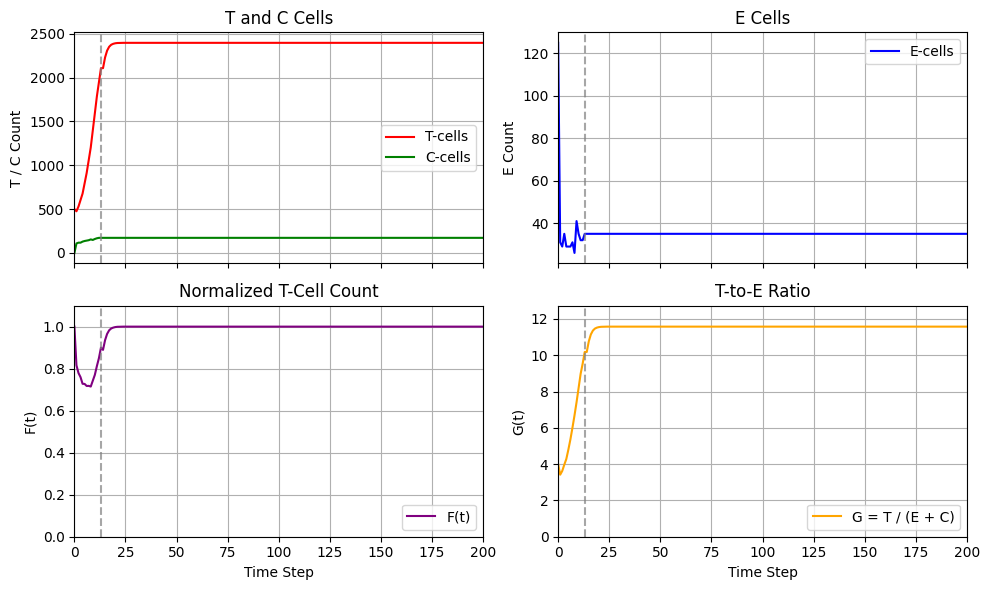

In [2]:
sim_config: dict = dict(
    E_0=125,
    T_0=500,
    r=0.02,
    m=0.02,
    N=200,
    L=1.0,
    # Binding and killing (double-binding behavior is already implemented)
    k_on=0.6,  # fairly strong chance to bind when contact is made
    k_off=0.02,  # low chance of unbinding
    k_kill=0.08,  # moderate chance to kill
    # Growth parameters
    g_T=0.121,
    K_T=4.792,  # in CI units
    A_T=1.421,  # in CI units
    g_E=0.191,
    K_E=0.544,  # in CI units
    activation_boost_per_T=0.035,
    activation_saturation_per_T2=0.009,
    early_stop=(True, 10.0, 0),
    seed=42,
    log_all=True,
    use_tqdm=True,
)
sim = tkd.WellSimulationV2(**sim_config)
sim.run()
sim.plot_history()

# Loading data to fit

In [3]:
# Load data to fit
df: pd.DataFrame = pd.read_csv("data/lab_data_from_hour_32.csv")
obs_T = np.array(df["tumor_cells_G1"])[::4] // 10
obs_T_initial = int(obs_T[0])
obs_E_initial = int(df["CART_cells_G1"].iloc[0]) // 10
obs_E_final = int(df["CART_cells_G1"].iloc[-1]) // 10

# ODE model trajectories by a research paper

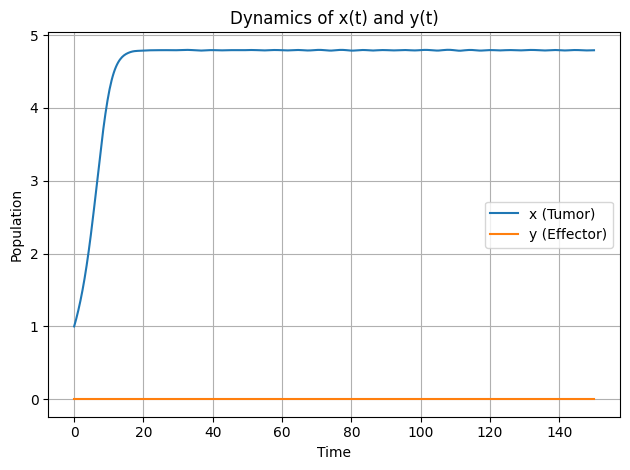

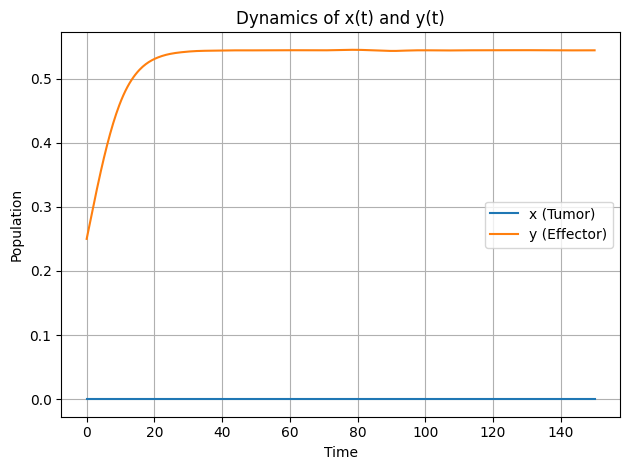

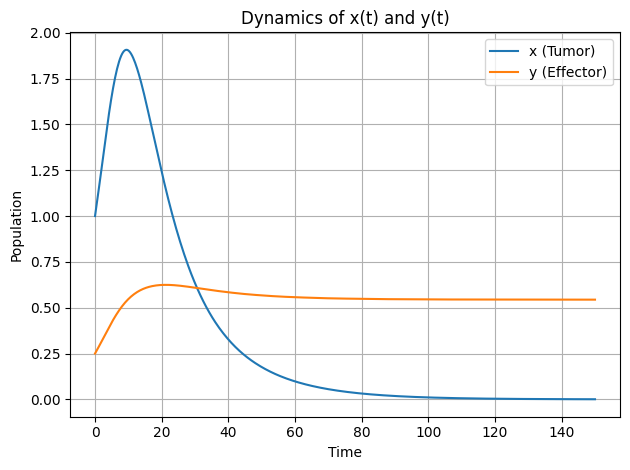

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ODE system
def ode_system1(t, z):
    x, y = z
    dxdt = 0.121 * x * (1 - x / 4.792) * (x / 1.421 + 1) - 0.593 * x * y**2
    dydt = 0  # 0.191 * y * (1 - y / 0.544) + 0.035 * x * y - 0.009 * x**2 * y
    return [dxdt, dydt]


# Time range and initial condition
t_span = (0, 150)
t_eval = np.linspace(*t_span, 500)
initial_condition = [1, 0]  # x(0), y(0)

# Solve
sol = solve_ivp(ode_system1, t_span, initial_condition, t_eval=t_eval)

# Plot
plt.plot(sol.t, sol.y[0], label="x (Tumor)")
plt.plot(sol.t, sol.y[1], label="y (Effector)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Dynamics of x(t) and y(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ODE system
def ode_system2(t, z):
    x, y = z
    dxdt = 0  # 0.121 * x * (1 - x / 4.792) * (x / 1.421 + 1) - 0.593 * x * y**2
    dydt = 0.191 * y * (1 - y / 0.544) + 0.035 * x * y - 0.009 * x**2 * y
    return [dxdt, dydt]


# Time range and initial condition
t_span = (0, 150)
t_eval = np.linspace(*t_span, 500)
initial_condition = [0, 0.25]  # x(0), y(0)

# Solve
sol = solve_ivp(ode_system2, t_span, initial_condition, t_eval=t_eval)

# Plot
plt.plot(sol.t, sol.y[0], label="x (Tumor)")
plt.plot(sol.t, sol.y[1], label="y (Effector)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Dynamics of x(t) and y(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ODE system
def ode_system3(t, z):
    x, y = z
    dxdt = 0.121 * x * (1 - x / 4.792) * (x / 1.421 + 1) - 0.593 * x * y**2
    dydt = 0.191 * y * (1 - y / 0.544) + 0.035 * x * y - 0.009 * x**2 * y
    return [dxdt, dydt]


# Time range and initial condition
t_span = (0, 150)
t_eval = np.linspace(*t_span, 500)
initial_condition = [1, 0.25]  # x(0), y(0)

# Solve
sol = solve_ivp(ode_system3, t_span, initial_condition, t_eval=t_eval)

# Plot
plt.plot(sol.t, sol.y[0], label="x (Tumor)")
plt.plot(sol.t, sol.y[1], label="y (Effector)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Dynamics of x(t) and y(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

ABOVE Plots:

- Plot 1: natural grow of T when no E is presenting
- Plot 2: natural grow of E when no T is presenting
- PLot 3: Both presenting

Simulating:   0%|          | 0/150 [00:00<?, ?it/s]

Output()

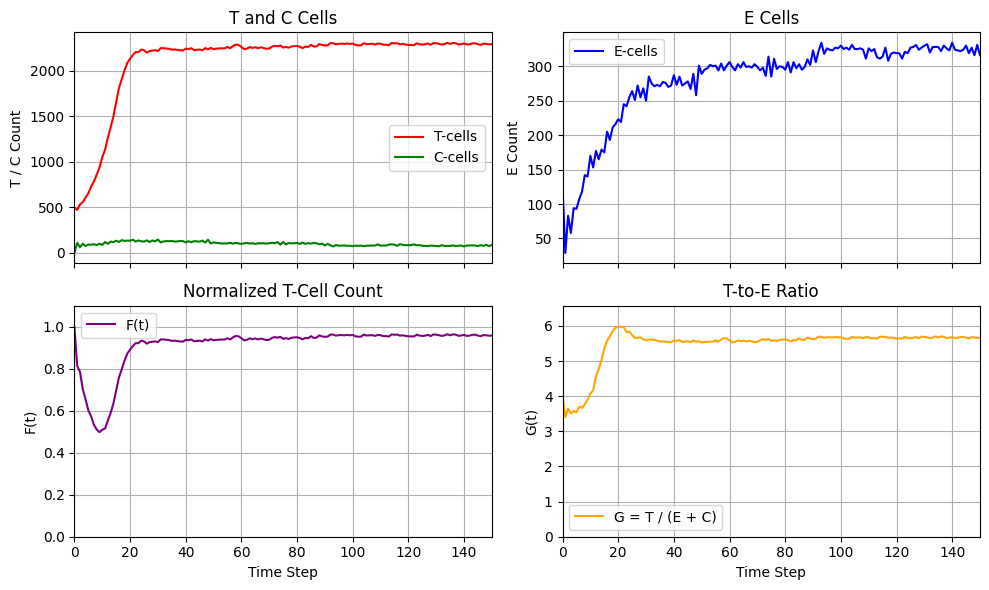

In [5]:
sim_config: dict = dict(
    E_0=125,
    T_0=500,
    r=0.02,
    m=0.02,
    N=150,
    L=1.0,
    k_on=0.6,
    k_off=0.02,
    k_kill=0.593,
    g_T=0.121,
    K_T=4.792,
    A_T=1.421,
    g_E=0.191,
    K_E=0.544,
    activation_boost_per_T=0.035,
    activation_saturation_per_T2=0.009,
    early_stop=(False, 10.0, 0),
    seed=42,
    log_all=True,
    use_tqdm=True,
)
sim = tkd.WellSimulationV2(**sim_config)
sim.run()
sim.plot_snapshot()
sim.plot_history()

We can try different parameters (or try to fit, do to this we need to change the code in ima_takeda), but we can't seem to replicate the behavior of E/T interaction correctly.

When E_0 and T_0 are set to 0, we can see our model does a fine job replicate the natural growth behavior (simulation T_0 = 0 is a little tricky and requires code override in ima_takeda, omitted here):

/Users/zedanliu/Documents/project/takeda_project/ima_takeda.py:1737: RuntimeWarning: divide by zero encountered in divide
  G: np.ndarray = np.where((E + C) > 0, T / (E + C), 0.0)


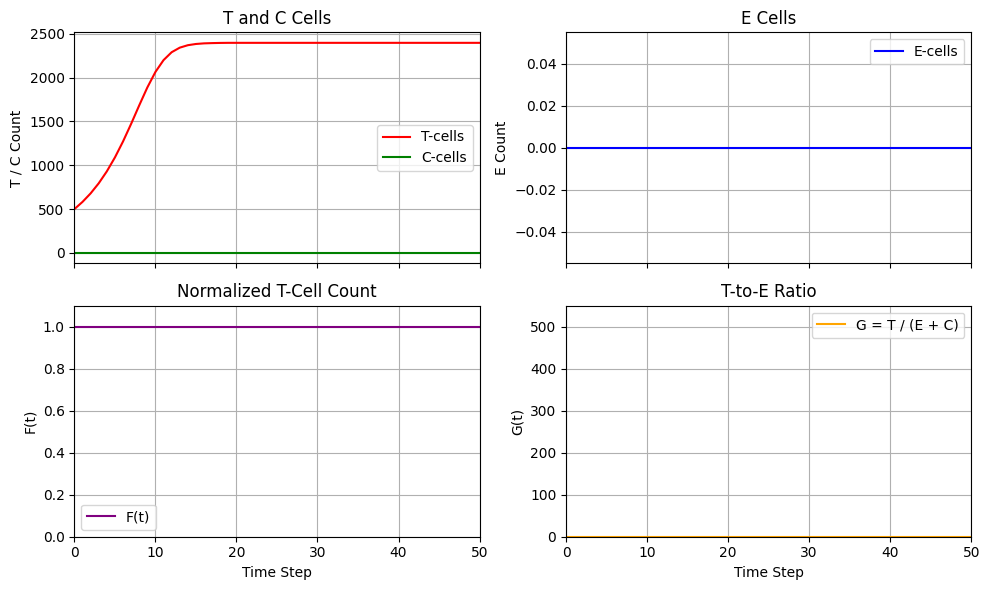

In [6]:
sim_config: dict = dict(
    E_0=0,
    T_0=500,
    r=0.02,
    m=0.02,
    N=50,
    L=1.0,
    k_on=0.6,
    k_off=0.02,
    k_kill=0.593,
    g_T=0.121,
    K_T=4.792,
    A_T=1.421,
    g_E=0.191,
    K_E=0.544,
    activation_boost_per_T=0.035,
    activation_saturation_per_T2=0.009,
    early_stop=(False, 10.0, 0),
    seed=42,
    log_all=True,
    use_tqdm=True,
)
sim = tkd.WellSimulationV2(**sim_config)
sim.run()
sim.plot_history()